### K-Means

In [45]:
import pandas as pd

path = '../../processed-data/elections/2009-2021_citizenship_election.csv' 

df = pd.read_csv(path)

df.columns


Index(['Unnamed: 0', 'Gruppe_x', 'PollingAreaID', 'Name', 'DistrictNo',
       'District', 'Municipality', 'Eligible voters', 'Voter turnout',
       'Blank votes', 'Other invalid votes', 'Valid votes', 'A', 'B', 'C', 'D',
       'F', 'I', 'J', 'G', 'K', 'N', 'H', 'M', 'U', 'Y', 'O', 'Z', 'L', 'Q',
       'R', 'V', 'P', 'E', 'Ø', 'Å', '1', '2', '3', 'T', 'Æ', 'year', '01',
       '02', '03', '04', '05', '06', '0', 'Gruppe_y', 'Valgsted navn',
       'KredsNr', 'Kreds navn', 'Kommune navn', 'Citizenship_Denmark',
       'Citizenship_Nordic', 'Citizenship_Turkey',
       'Citizenship_Former Yugoslavia', 'Citizenship_Old EU countries',
       'Citizenship_New EU countries', 'Citizenship_Other Europe',
       'Citizenship_Africa', 'Citizenship_North America',
       'Citizenship_South and Central America', 'Citizenship_Asia and Oceania',
       'Citizenship_Total', 'Citizenship_Not specified', 'Non Danish Share',
       'turnout_q25', 'low_turnout', 'consistent_low_turnout'],
      dtype='

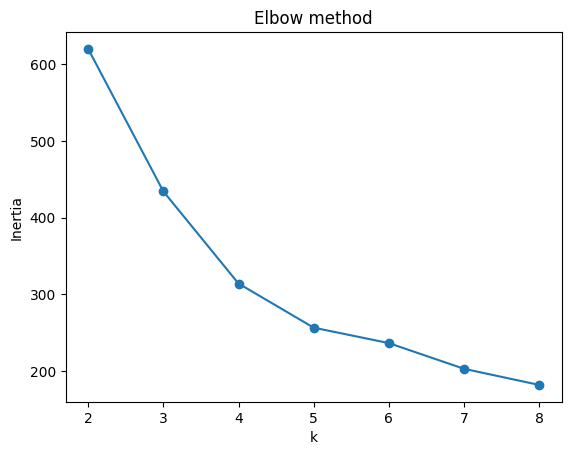

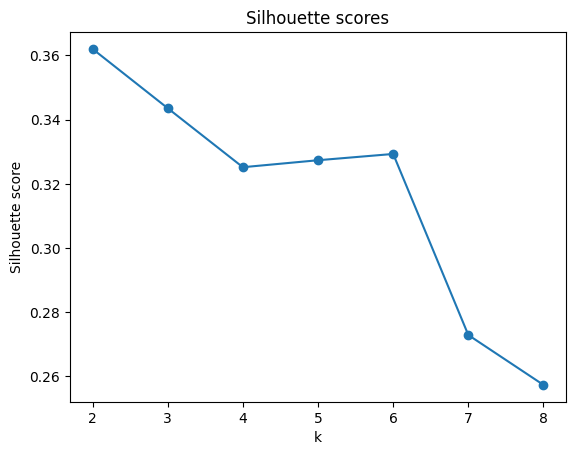

In [46]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Drop the extra index column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Ensure year is numeric
df["year"] = pd.to_numeric(df["year"], errors="coerce")

party_cols = [
    'A','B','C','D','F','I','J','G','K','N','H','M','U','Y','O','Z','L','Q',
    'R','V','P','E','Ø','Å','T','Æ',
    '0','01','02','03','04','05','06','1','2','3'
]

# Keep only those that actually exist in df
party_cols = [c for c in party_cols if c in df.columns]

# Convert party columns to numeric 
for c in party_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# == Create political summary features ==

# Party dominance (largest party share)
df["party_dominance"] = df[party_cols].max(axis=1)

# Party fragmentation
df["party_fragmentation"] = 1 - (df[party_cols] ** 2).sum(axis=1)

# Select features for K-Means
features = [
    "Non Danish Share",     # already a %
    "Voter turnout",        # already a %
    "party_dominance",
    "party_fragmentation"
]

X = (
    df[features]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ks = range(2, 9)

# Elbow
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

# Silhouette
sils = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    sils.append(silhouette_score(X_scaled, labels))

plt.plot(list(ks), sils, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette scores")
plt.show()

The elbow plot shows a steep decrease in inertia up to k = 3 or 4, after which the improvements become marginal. This suggests that adding more clusters beyond this point does not substantially improve cluster compactness.

The silhouette score is highest for k = 2, but remains relatively stable for k = 3. For larger k, the score decreases, indicating poorer cluster separation.

In [47]:
best_k = None
best_score = -1

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    if score > best_score:
        best_k = k
        best_score = score

print("Best k by silhouette:", best_k)
print("Silhouette score:", best_score)


Best k by silhouette: 2
Silhouette score: 0.36202947747866987


In [48]:
inertias = np.array(inertias)  # from elbow code
second_diff = np.diff(inertias, n=2)

elbow_k = np.argmin(second_diff) + 2  # +2 because diff shrinks array
print("Elbow k (approx):", elbow_k)


Elbow k (approx): 5


In [49]:
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    print(f"\n--- k = {k} ---")
    print(pd.DataFrame(X, columns=features).assign(cluster=labels)
          .groupby("cluster").mean())



--- k = 2 ---
         Non Danish Share  Voter turnout  party_dominance  party_fragmentation
cluster                                                                       
0               15.600062      60.922450        27.378960         -1620.919595
1               16.789842      60.610589        37.011112         -2110.563767

--- k = 3 ---
         Non Danish Share  Voter turnout  party_dominance  party_fragmentation
cluster                                                                       
0               15.955646      60.632499        27.273721         -1616.509969
1               50.648077      37.841180        42.182229         -2604.308888
2               13.363395      63.018790        36.258462         -2053.545080

--- k = 4 ---
         Non Danish Share  Voter turnout  party_dominance  party_fragmentation
cluster                                                                       
0               13.881309      64.756375        26.703892         -1572.805116
1      

We evaluated the number of clusters using both silhouette scores and the elbow method. The silhouette score was highest for k = 2, indicating a strong binary separation. However, the elbow method suggested additional structure around k = 4–5. We therefore chose k = 3 as a compromise that balances clustering quality with interpretability and aligns with our research question.

Why is party fragmentation negative? Party fragmentation was used as a relative measure of vote dispersion. Since all features were standardized before clustering, the scale does not affect the clustering outcome.

Using k = 3, we identify three distinct types of polling areas. We named the clusters based on which characteristics clearly distinguish them: one cluster has very high diversity and very low turnout, one has low diversity and high turnout, and the third sits in between demographically but stands out due to fragmented party support.

In [50]:
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init="auto"
)

# Fit the model on the standardized feature matrix and assign each polling area to a cluster
df.loc[X.index, "cluster"] = kmeans.fit_predict(X_scaled)

#Compute average values of the clustering features for each cluster to support interpretation
cluster_summary = (
    df.groupby("cluster")[features]
      .mean()
      .round(2)
)

cluster_summary

# Cluster labels are based on the observed averages and are descriptive rather than evaluative
cluster_labels = {
    0: "Moderate diversity, fragmented politics",
    1: "High diversity, low turnout",
    2: "Low diversity, high turnout"
}

df["cluster_label"] = df["cluster"].map(cluster_labels)

# Check how many polling areas fall into each cluster to ensure clusters are not driven by outliers
df["cluster_label"].value_counts()



cluster_label
Moderate diversity, fragmented politics    155
Low diversity, high turnout                 57
High diversity, low turnout                  4
Name: count, dtype: int64

The clusters are not evenly sized, which reflects the underlying structure of the data rather than a modeling issue. Most polling areas exhibit moderate diversity and fragmented political competition. A smaller group shows low diversity and consistently high turnout. Finally, a very small cluster captures polling areas with exceptionally high non-Danish population shares and substantially lower turnout. Although this group is small, it represents a distinct and substantively important pattern.

In [51]:
# Check which years appear in the small cluster
df[df["cluster_label"] == "High diversity, low turnout"]["year"].value_counts()

year
2009    1
2013    1
2017    1
2021    1
Name: count, dtype: int64

Although the high-diversity, low-turnout cluster is small, it appears consistently across all election years in the dataset. This suggests that it represents a persistent structural pattern rather than a year-specific anomaly.

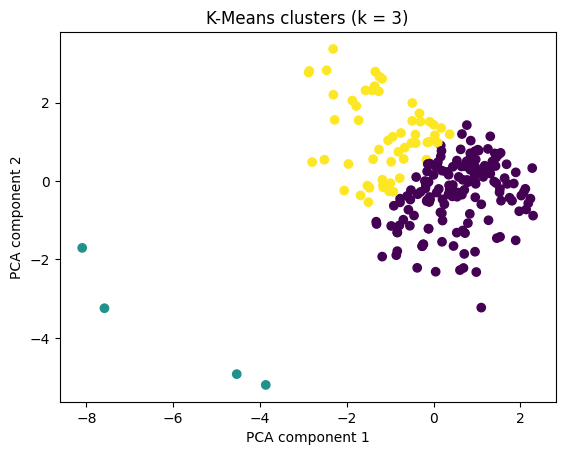

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df.loc[X.index, "cluster"],
)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("K-Means clusters (k = 3)")
plt.show()


We use PCA only to visualize the K-Means clusters in two dimensions. The clustering itself was done in the original feature space.

The spatial separation of the small cluster indicates that it represents a genuinely distinct pattern rather than noise.

The PCA visualization supports the choice of k = 3 by showing clear separation without over-fragmentation.

This PCA plot visualizes the K-Means clusters in two dimensions. Although clustering was performed in the original standardized feature space, PCA allows us to assess how well the clusters separate. We observe a large central cluster representing moderate diversity and fragmented politics, a distinct cluster with low diversity and high turnout, and a small but clearly separated cluster characterized by very high diversity and low turnout. This visual separation supports both the interpretability of the clusters and our choice of k.

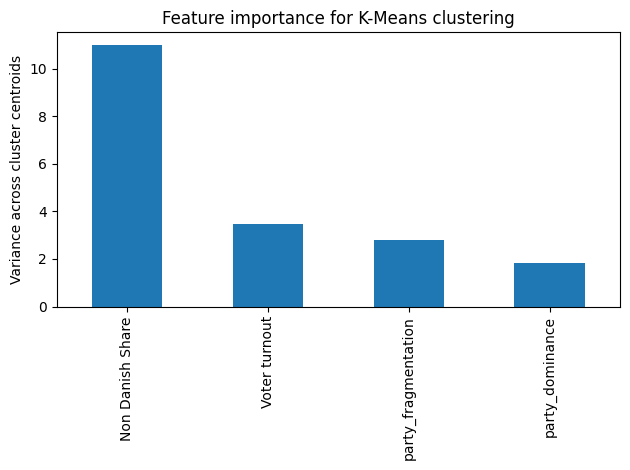

In [53]:
# Centroids in standardized feature space
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features
)

centroids

feature_importance = centroids.var().sort_values(ascending=False)
feature_importance

plt.figure()
feature_importance.plot(kind="bar")
plt.ylabel("Variance across cluster centroids")
plt.title("Feature importance for K-Means clustering")
plt.tight_layout()
plt.show()

The clustering is primarily driven by differences in migration composition, with voter turnout as the second most important distinguishing factor. Political structure, measured by party dominance and fragmentation, plays a secondary but still meaningful role.

SIDENOTE: We first clustered polling areas using overall non-Danish share to identify broad patterns, and then refined the analysis by incorporating detailed origin groups, which revealed more nuanced and substantively meaningful clusters.

In [54]:
origin_cols = [
    "Citizenship_Nordic",
    "Citizenship_Turkey",
    "Citizenship_Former Yugoslavia",
    "Citizenship_Old EU countries",
    "Citizenship_New EU countries",
    "Citizenship_Other Europe",
    "Citizenship_Africa",
    "Citizenship_North America",
    "Citizenship_South and Central America",
    "Citizenship_Asia and Oceania"
]

# Keep only columns that exist (safe)
origin_cols = [c for c in origin_cols if c in df.columns]


Exclude the Danish category and totals to avoid linear dependence in compositional data

In [55]:
features_full = (
    origin_cols
    + ["Voter turnout", "party_dominance", "party_fragmentation"]
)

X_full = (
    df[features_full]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

In [56]:
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

All features were standardized to prevent high-variance origin groups from dominating distance calculations.

In [57]:
k = 3

# Fit K-Means on origin-based features
kmeans_full = KMeans(
    n_clusters=k,
    random_state=42,
    n_init="auto"
)

labels_full = kmeans_full.fit_predict(X_full_scaled)

# Store numeric cluster IDs
df.loc[X_full.index, "cluster_origins"] = labels_full

cluster_profile_full = (
    df.groupby("cluster_origins")[features_full]
      .mean()
      .round(2)
)

cluster_profile_full

,Citizenship_Nordic,Citizenship_Turkey,Citizenship_Former Yugoslavia,Citizenship_Old EU countries,Citizenship_New EU countries,Citizenship_Other Europe,Citizenship_Africa,Citizenship_North America,Citizenship_South and Central America,Citizenship_Asia and Oceania,Voter turnout,party_dominance,party_fragmentation
cluster_origins,,,,,,,,,,,,,
0.0,1.38,1.77,2.11,3.14,3.17,0.31,2.94,0.29,0.37,7.56,50.71,33.00,-1883.38
1.0,2.84,0.39,0.49,5.25,1.79,0.43,0.63,0.89,0.61,2.89,63.91,26.76,-1574.88
2.0,1.92,0.59,0.75,3.06,1.60,0.27,0.96,0.47,0.39,3.48,61.90,30.98,-1819.78


(Party dominance measures how strong the largest party is, while party fragmentation measures how dispersed votes are across parties; together they summarize political competition without relying on specific party labels.)

In [58]:
cluster_names_origins = {
    0: "Non-European origin concentration, low turnout",
    1: "European-origin mix, high turnout",
    2: "Mixed-origin composition, moderate participation"
}

df["cluster_name_origins"] = df["cluster_origins"].map(cluster_names_origins)

In [59]:
centroids_full = pd.DataFrame(
    kmeans_full.cluster_centers_,
    columns=features_full
)

feature_importance_full = centroids_full.var().sort_values(ascending=False)
feature_importance_full

Citizenship_Turkey                       1.235932
Citizenship_Africa                       1.034703
Citizenship_Asia and Oceania             0.989689
Citizenship_North America                0.938526
Voter turnout                            0.903484
Citizenship_Nordic                       0.834317
Citizenship_Former Yugoslavia            0.826428
Citizenship_Old EU countries             0.590449
Citizenship_New EU countries             0.582729
Citizenship_South and Central America    0.429079
Citizenship_Other Europe                 0.376700
party_dominance                          0.332466
party_fragmentation                      0.303697
dtype: float64

We assess the importance of origin groups by measuring how much cluster centroids differ across each group. When we include all origin groups, the clustering is primarily driven by differences in the composition of migration origins, particularly shares of residents from Turkey, Africa, and Asia/Oceania. Voter turnout plays a secondary role, while party dominance and fragmentation contribute less to the separation.

In [60]:
df.loc[X_full.index, "cluster_origins"].value_counts()

cluster_origins
2.0    113
1.0     70
0.0     33
Name: count, dtype: int64

C:\Users\Johanne Auener\AppData\Local\Temp\ipykernel_18848\3321675307.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap("Set2", k)           # sample k colors from Set2


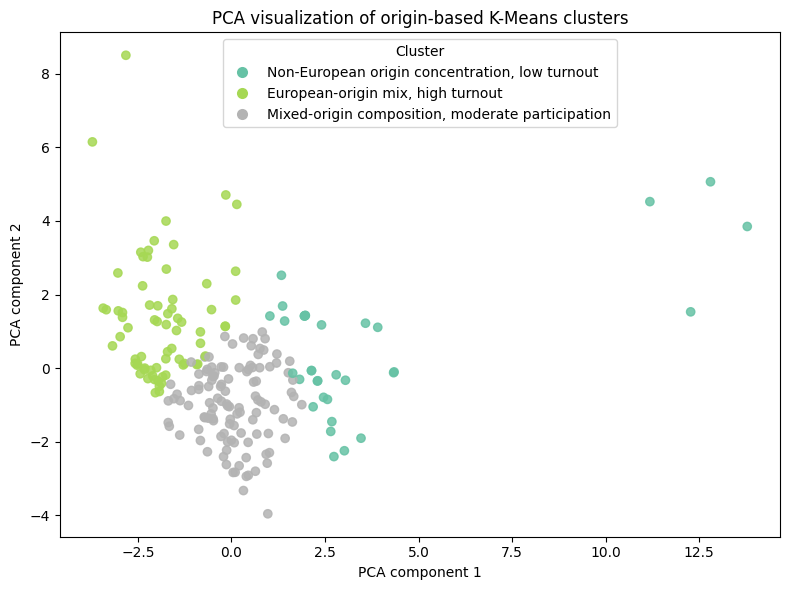

In [61]:
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

# PCA for visualization only
pca = PCA(n_components=2, random_state=42)
X_full_pca = pca.fit_transform(X_full_scaled)

# Make sure cluster ids are integers (sometimes they show up as 0.0, 1.0, 2.0)
clusters = df.loc[X_full.index, "cluster_origins"].astype(int).values

#  Define cluster names (make sure keys are ints)
cluster_names_origins = {
    0: "Non-European origin concentration, low turnout",
    1: "European-origin mix, high turnout",
    2: "Mixed-origin composition, moderate participation"
}

# Create a colormap with k colors
k = len(cluster_names_origins)
base = plt.cm.get_cmap("Set2", k)           # sample k colors from Set2
colors = base(np.arange(k))                 # actual RGBA colors
cmap = ListedColormap(colors)

# Plot points, using the same discrete mapping 
plt.figure(figsize=(8, 6))
plt.scatter(
    X_full_pca[:, 0],
    X_full_pca[:, 1],
    c=clusters,
    cmap=cmap,
    vmin=-0.5, vmax=k-0.5,   # forces discrete color bins centered on 0,1,2
    alpha=0.85
)

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("PCA visualization of origin-based K-Means clusters")

# Legend with matching colors 
legend_elements = [
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor=colors[i], markeredgecolor='none',
           label=cluster_names_origins[i], markersize=8)
    for i in range(k)
]

plt.legend(handles=legend_elements, title="Cluster", loc="upper center")
plt.tight_layout()

plt.savefig(
    "pca_kmeans_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The PCA plot confirms that the origin-based K-Means model identifies meaningful and interpretable clusters. Polling areas with high non-European origin shares form a clearly distinct group with lower voter turnout, while areas with European or mixed migration compositions cluster more closely together and show higher participation levels. This indicates that migration origin composition provides a more nuanced explanation of turnout differences than overall migration share alone.

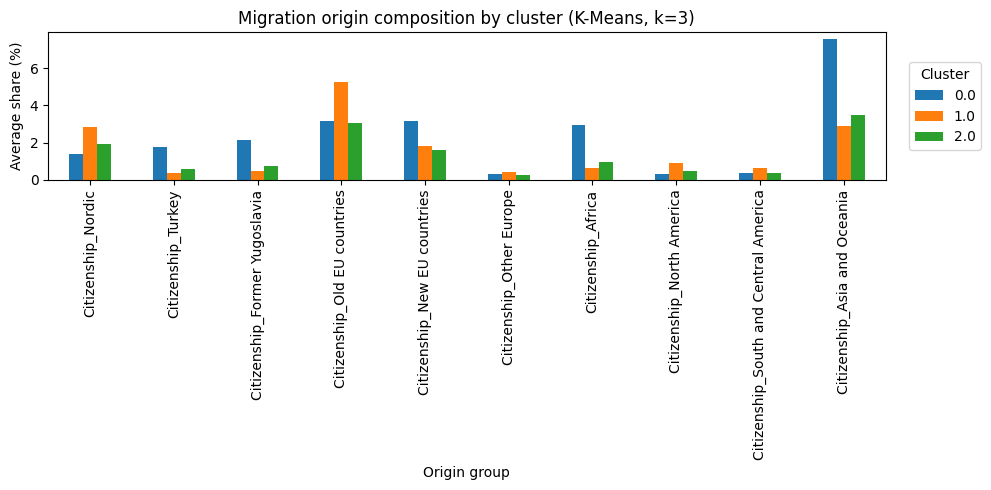

In [62]:
origin_profile = (
    df.loc[X_full.index]
      .groupby("cluster_origins")[origin_cols]
      .mean()
)

origin_profile.T.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Average share (%)")
plt.xlabel("Origin group")
plt.title("Migration origin composition by cluster (K-Means, k=3)")

plt.legend(
    title="Cluster",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()

plt.savefig(
    "migration_origin_composition.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

This plot shows that clusters differ not only in the amount of migration but in its composition. Polling areas with predominantly non-European origins form a distinct cluster, while European-origin and mixed-origin areas display different migration profiles, supporting the interpretation of the K-Means results.

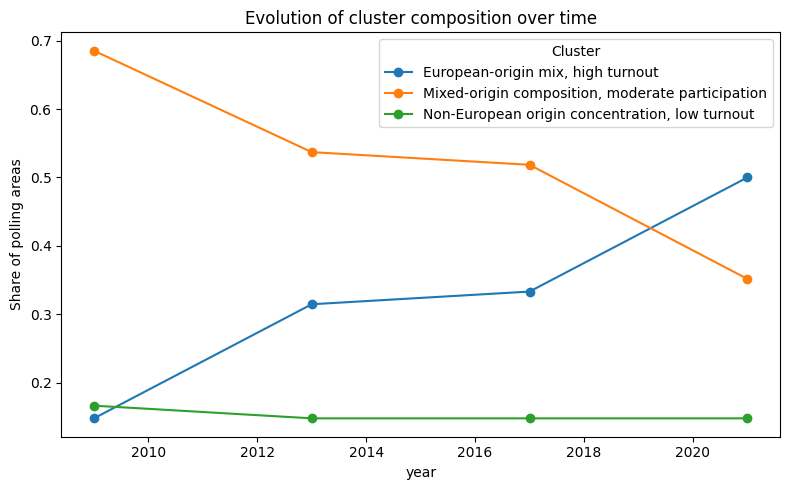

In [63]:
# Count cluster membership per year
cluster_time = (
    df.loc[X_full.index]
      .groupby(["year", "cluster_name_origins"])
      .size()
      .unstack(fill_value=0)
)

# Normalize to proportions
cluster_time_prop = cluster_time.div(cluster_time.sum(axis=1), axis=0)

cluster_time_prop.plot(kind="line", marker="o", figsize=(8, 5))

plt.ylabel("Share of polling areas")
plt.title("Evolution of cluster composition over time")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

The temporal evolution of cluster membership reveals clear structural changes in the composition of polling areas over time. The share of areas characterized by a European-origin migration mix and high voter turnout increases steadily across elections, while areas with mixed-origin compositions and moderate participation decline. In contrast, polling areas with a concentrated non-European origin and low turnout remain a small but persistent group. This suggests that migration-participation profiles are dynamic and that changes in migration composition over time are associated with broader shifts in electoral participation patterns.

### Decision Trees

We first used K-Means to identify latent structures in migration and participation patterns. We then used Decision Trees to explain and validate these patterns by identifying which variables and thresholds best predict turnout outcomes.

We first used K-Means clustering to identify latent structures in turnout and citizenship composition across polling areas. We then applied Decision Tree models to explain these structures by identifying which citizenship shares and political features best separate turnout outcomes.
Research question:
"Which citizenship composition features and thresholds separate the three turnout–origin clusters?"

IDEA 1 - Decision Tree to predict low turnout - “Which migration-origin features best explain low turnout areas?

IDEA 2 - Decision Tree to predict cluster membership - “What rules separate the K-Means clusters?”

In [20]:
#exclude_cols = ['Voter turnout', 'low_turnout', 'turnout_q25']
df

,Gruppe_x,PollingAreaID,Name,DistrictNo,District,Municipality,Eligible voters,Voter turnout,Blank votes,Other invalid votes,...,Non Danish Share,turnout_q25,low_turnout,consistent_low_turnout,party_dominance,party_fragmentation,cluster,cluster_label,cluster_origins,cluster_name_origins
0,101001,101001,1. Østerbro,1,1. Østerbro,København,11209.98,61.405997,1.220001,0.182463,...,10.540062,50.639384,False,False,26.298171,-1688.082845,0.0,"Moderate diversity, fragmented politics",2.0,"Mixed-origin composition, moderate participation"
1,101002,101002,1. Nord,1,1. Østerbro,København,6096.00,57.529528,0.998004,0.342173,...,11.985571,50.639384,False,False,26.647399,-1626.087440,0.0,"Moderate diversity, fragmented politics",2.0,"Mixed-origin composition, moderate participation"
2,101003,101003,1. Syd,1,1. Østerbro,København,12272.62,59.915731,0.891037,0.178425,...,12.057866,50.639384,False,False,26.259451,-1652.389802,0.0,"Moderate diversity, fragmented politics",1.0,"European-origin mix, high turnout"
3,101005,101005,1. Vest,1,1. Østerbro,København,11459.00,54.516101,0.912438,0.320154,...,12.094395,50.639384,False,False,30.259319,-1788.469094,0.0,"Moderate diversity, fragmented politics",2.0,"Mixed-origin composition, moderate participation"
4,101006,101006,1. Nordvest,1,1. Østerbro,København,9866.00,57.601865,1.266936,0.246349,...,11.968167,50.639384,False,False,30.534215,-1754.462939,0.0,"Moderate diversity, fragmented politics",2.0,"Mixed-origin composition, moderate participation"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,147003,147003,"10. Kreds, Bülowsvej",10,10. Falkoner,Frederiksberg,12391.00,75.796949,0.830494,0.212947,...,15.431706,55.764212,False,False,37.508070,-2235.558439,2.0,"Low diversity, high turnout",1.0,"European-origin mix, high turnout"
228,147004,147004,"10. Kreds, Duevej",10,10. Falkoner,Frederiksberg,11558.00,73.317183,0.778853,0.165211,...,14.424149,55.764212,False,False,39.063617,-2274.833930,2.0,"Low diversity, high turnout",2.0,"Mixed-origin composition, moderate participation"
229,147005,147005,"11. Kreds, Lindevang",11,11. Slots,Frederiksberg,11849.00,65.853659,0.935538,0.333205,...,14.754805,55.764212,False,False,37.798546,-2263.482234,2.0,"Low diversity, high turnout",2.0,"Mixed-origin composition, moderate participation"
230,147006,147006,"11. Kreds, Søndermark",11,11. Slots,Frederiksberg,10092.00,71.294094,0.847811,0.361362,...,12.210232,55.764212,False,False,42.473270,-2527.475765,2.0,"Low diversity, high turnout",2.0,"Mixed-origin composition, moderate participation"


In [64]:
#Checking the null values in cluster
null_df = df[df[['cluster_origins']].isna().all(axis=1)]

In [65]:
null_df

,Gruppe_x,PollingAreaID,Name,DistrictNo,District,Municipality,Eligible voters,Voter turnout,Blank votes,Other invalid votes,...,Non Danish Share,turnout_q25,low_turnout,consistent_low_turnout,party_dominance,party_fragmentation,cluster,cluster_label,cluster_origins,cluster_name_origins
6,101008,101010;101008,2. Vest;2. Nord,2,2. Sundbyvester,København,22563.00,51.611045,0.987548,0.231859,...,NaN,50.639384,False,False,31.409198,-1788.221305,NaN,NaN,NaN,NaN
7,101009,101009,2. Syd,2,2. Sundbyvester,København,7472.09,47.800816,0.825373,0.242740,...,NaN,50.639384,True,False,27.975390,-1704.040125,NaN,NaN,NaN,NaN
11,101014,101057;101014,2. Øst;3. Øst,2;3,2. Sundbyvester;3. Indre By,København,16198.38,54.618610,0.900385,0.155753,...,NaN,50.639384,False,False,27.025045,-1587.393030,NaN,NaN,NaN,NaN
57,147007,147008;147007,"11. Kreds, Nyelandsvej;11. Kreds, Rådhuset",11,11. Slots,Frederiksberg,18862.00,63.710105,0.907048,0.116502,...,NaN,50.639384,False,False,37.228855,-2326.630406,NaN,NaN,NaN,NaN
64,101008,101010;101008,2. Vest;2. Nord,2,2. Sundbyvester,København,24716.00,62.760965,1.282878,0.328778,...,NaN,58.319119,False,False,27.414494,-1578.789903,NaN,NaN,NaN,NaN
65,101009,101009,2. Syd,2,2. Sundbyvester,København,9294.79,58.822954,1.558308,0.405123,...,NaN,58.319119,False,False,24.415871,-1454.072047,NaN,NaN,NaN,NaN
69,101014,101057;101014,2. Øst;3. Øst,2;3,2. Sundbyvester;3. Indre By,København,18760.96,60.175972,1.662771,0.514633,...,NaN,58.319119,False,False,24.910696,-1454.040561,NaN,NaN,NaN,NaN
115,147007,147008;147007,"11. Kreds, Nyelandsvej;11. Kreds, Rådhuset",11,11. Slots,Frederiksberg,20135.00,69.332009,1.153295,0.286533,...,NaN,58.319119,False,False,35.932844,-1990.603870,NaN,NaN,NaN,NaN
122,101008,101010;101008,2. Vest;2. Nord,2,2. Sundbyvester,København,26644.00,62.599460,1.169135,0.473649,...,NaN,58.341034,False,False,25.943310,-1413.317246,NaN,NaN,NaN,NaN
123,101009,101009,2. Syd,2,2. Sundbyvester,København,12123.99,54.180843,1.242373,0.461114,...,NaN,58.341034,True,False,22.866382,-1308.284468,NaN,NaN,NaN,NaN


In [23]:
print(df.isnull().sum())


Gruppe_x                 0
PollingAreaID            0
Name                     0
DistrictNo               0
District                 0
                        ..
party_fragmentation      0
cluster                 16
cluster_label           16
cluster_origins         16
cluster_name_origins    16
Length: 76, dtype: int64


In [66]:
# Seperating into y and X

# X, the same as k-means except no voter turnout
from sklearn.model_selection import train_test_split

origin_cols = [
    "Citizenship_Nordic",
    "Citizenship_Turkey",
    "Citizenship_Former Yugoslavia",
    "Citizenship_Old EU countries",
    "Citizenship_New EU countries",
    "Citizenship_Other Europe",
    "Citizenship_Africa",
    "Citizenship_North America",
    "Citizenship_South and Central America",
    "Citizenship_Asia and Oceania"
]

# Keep only columns that exist
origin_cols = [c for c in origin_cols if c in df.columns]

features_full = (
    origin_cols
    + ["party_dominance", "party_fragmentation"]
)

X_full = (
    df[features_full]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)


#y (dropping na's)
y = df["cluster_origins"].dropna()

#Split into train and test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#stratisfy makes sure that each cluster is represented proportionally in train and test data.


In [67]:
from sklearn.tree import DecisionTreeClassifier

cluster_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=30,
    random_state=42
)

cluster_tree.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,30
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [68]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
#Evaluation the tree

y_pred = cluster_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.57

Classification report:

              precision    recall  f1-score   support

         0.0       0.27      0.43      0.33         7
         1.0       0.64      0.64      0.64        14
         2.0       0.68      0.57      0.62        23

    accuracy                           0.57        44
   macro avg       0.53      0.55      0.53        44
weighted avg       0.61      0.57      0.58        44



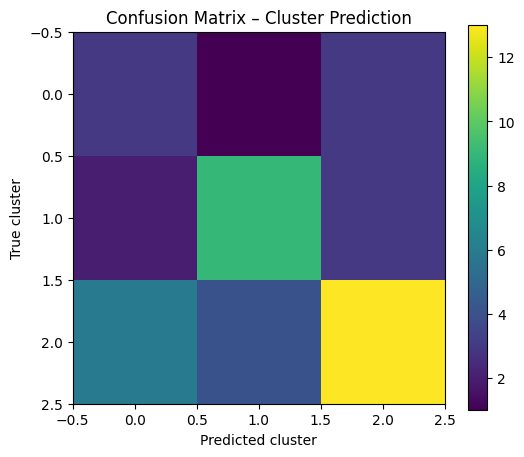

In [69]:
from sklearn.metrics import confusion_matrix

# Making and plotting a confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix – Cluster Prediction")
plt.xlabel("Predicted cluster")
plt.ylabel("True cluster")
plt.colorbar()
plt.show()


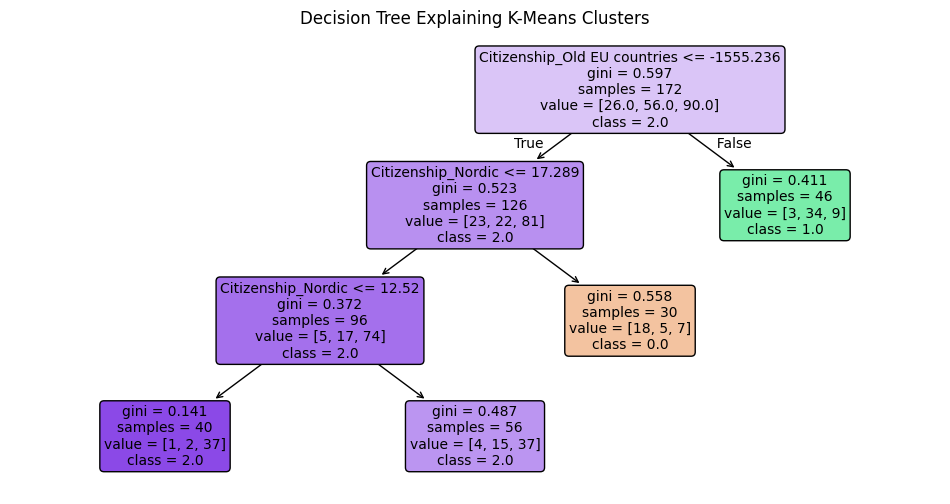

In [78]:
from sklearn.tree import plot_tree

#Plotting the decision tree
plt.figure(figsize=(12, 6))
plot_tree(
    cluster_tree,
    feature_names=features_full,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
)

plt.savefig(
    "cluster_d_tree.png",
    dpi=300,
    bbox_inches="tight"
)
plt.title("Decision Tree Explaining K-Means Clusters")
plt.show()
